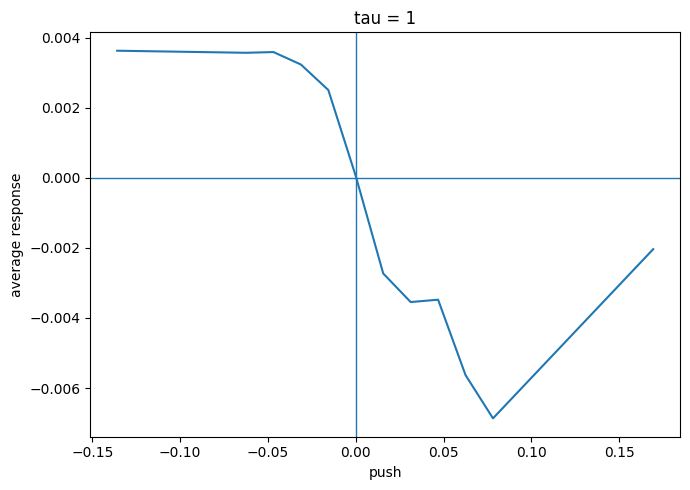

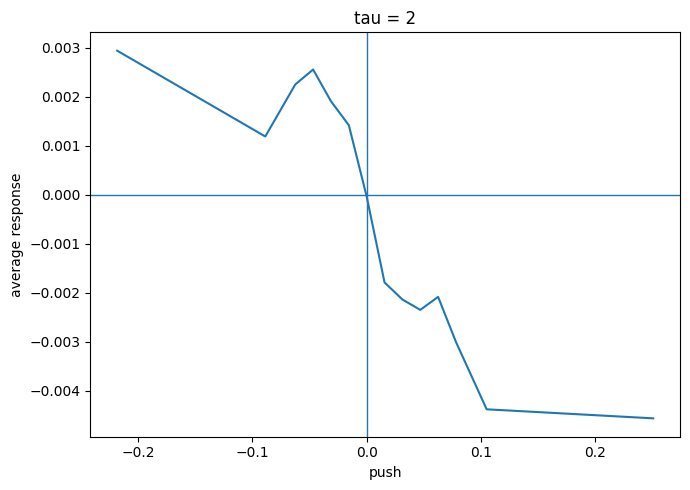

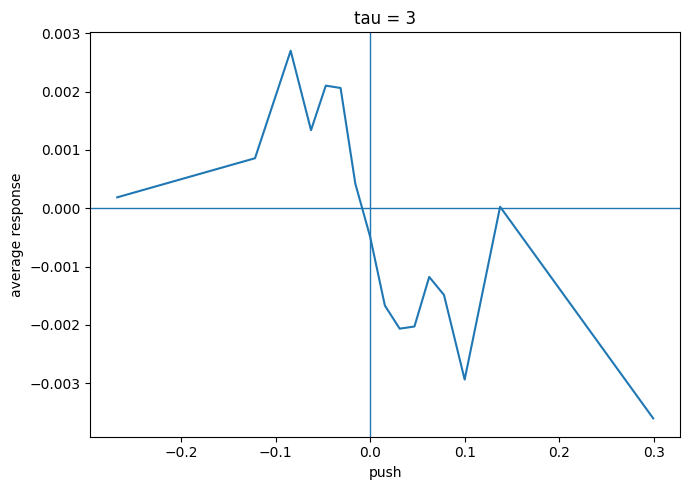

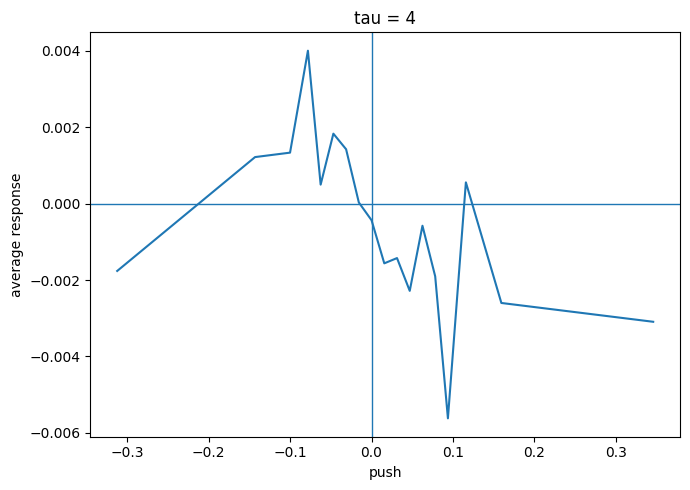

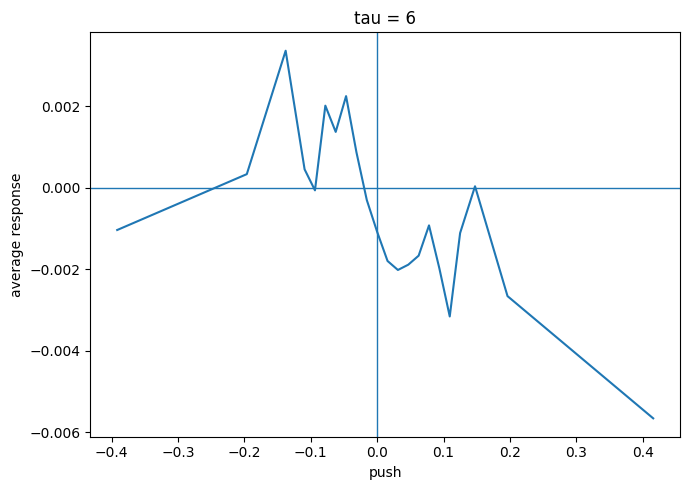

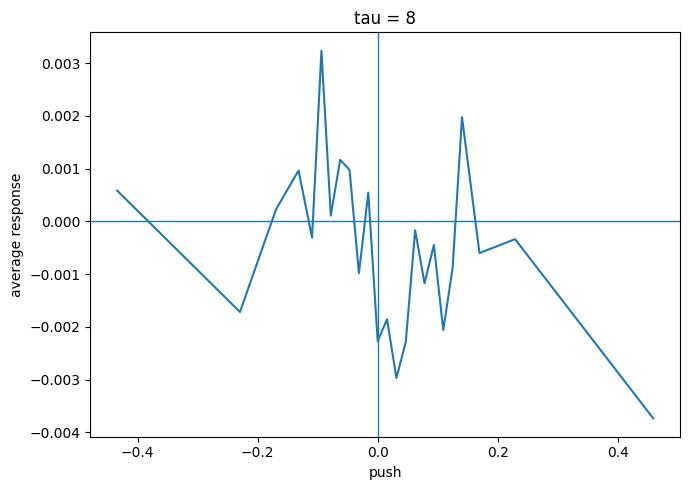

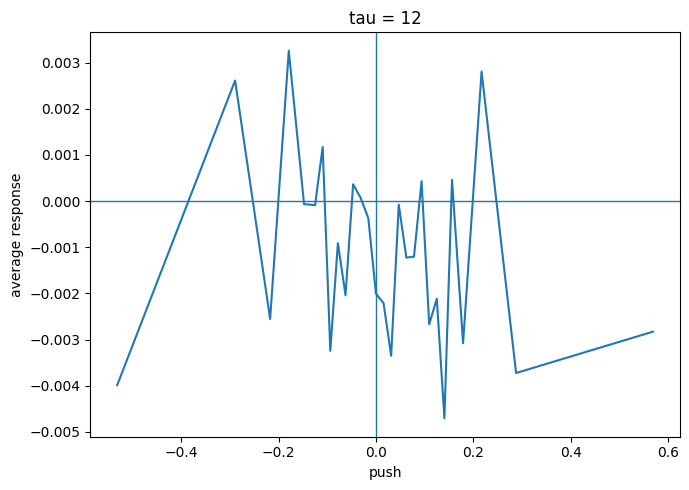

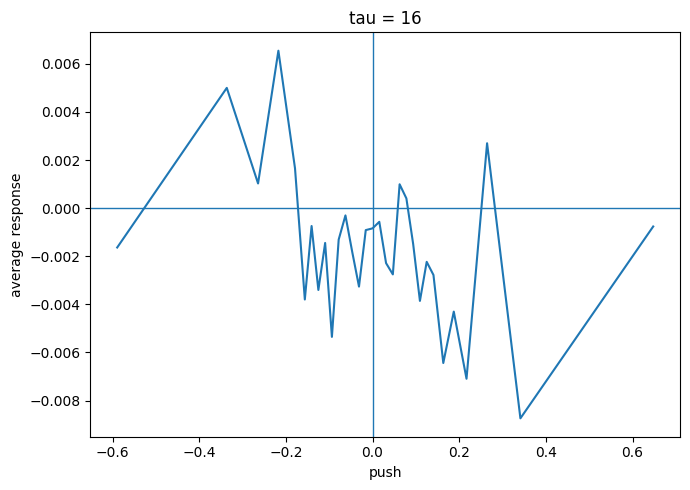

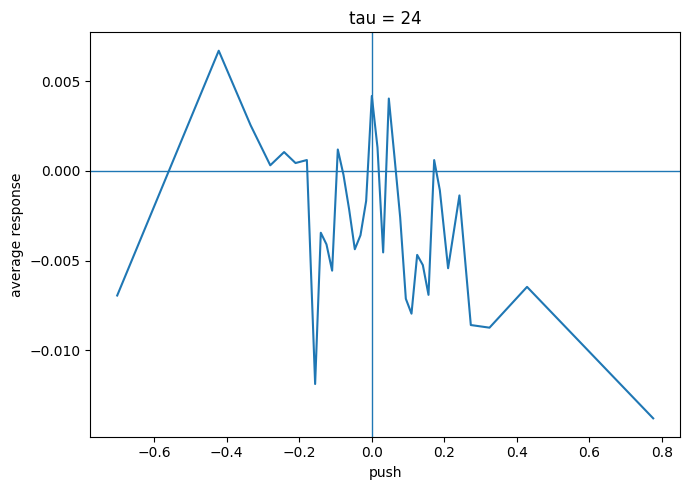

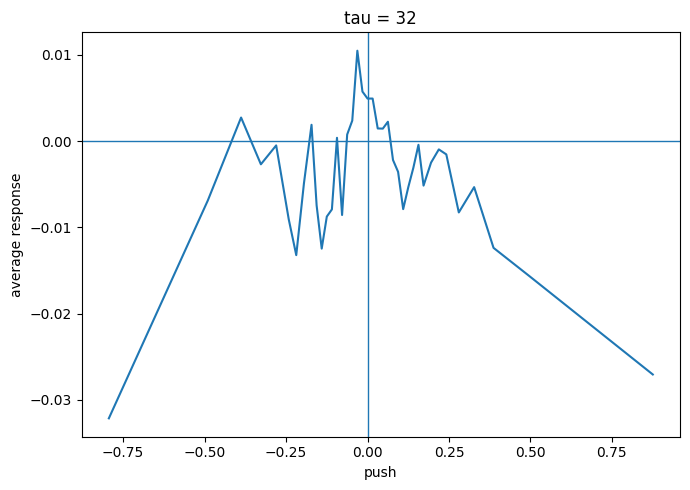

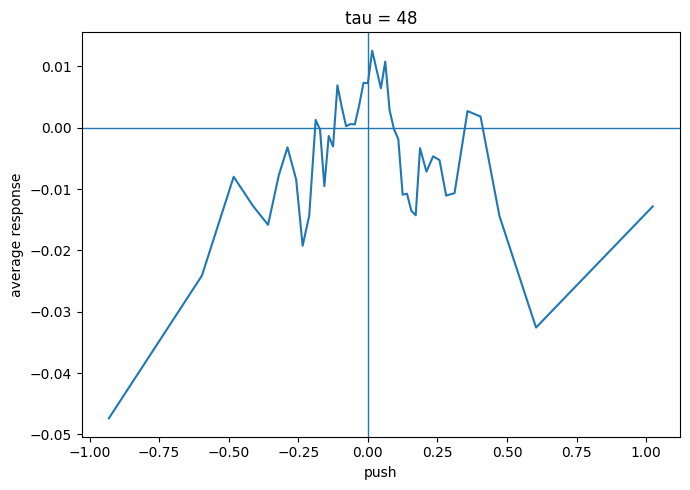

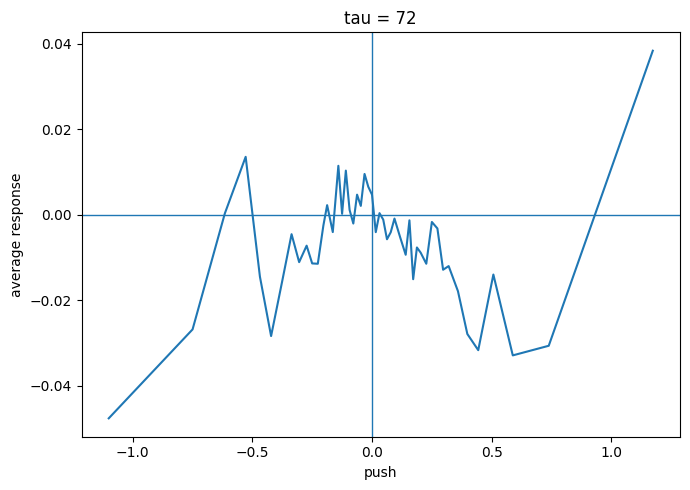

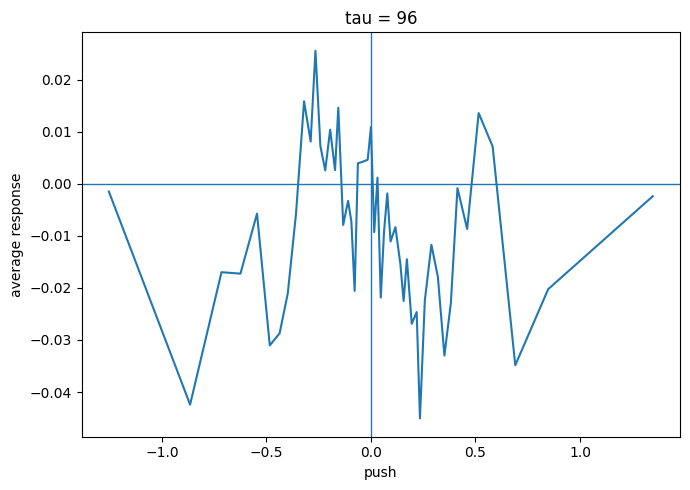

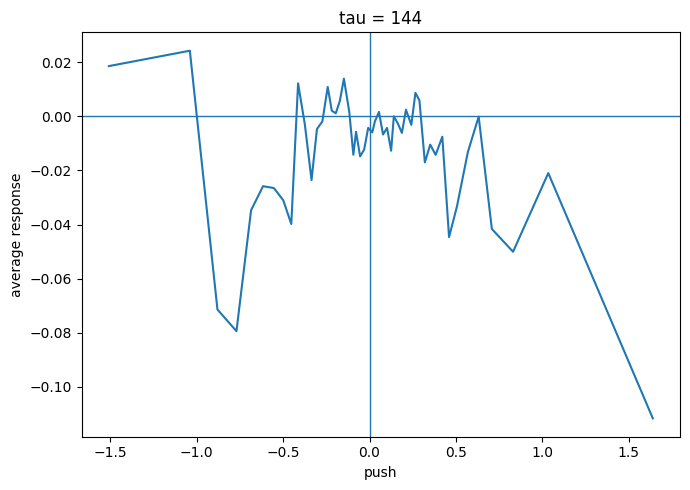

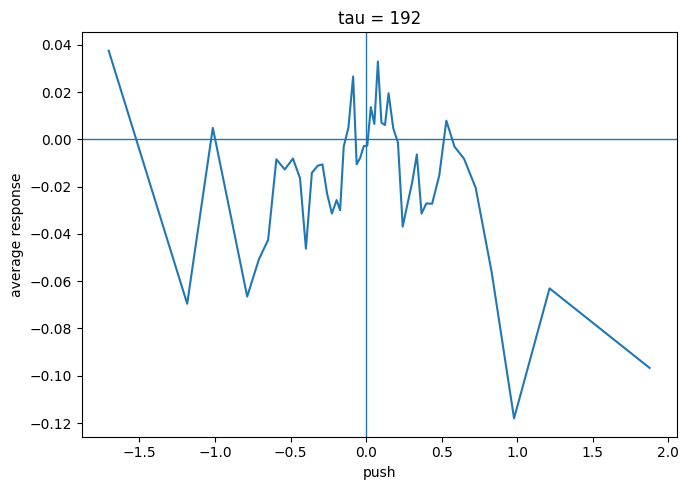

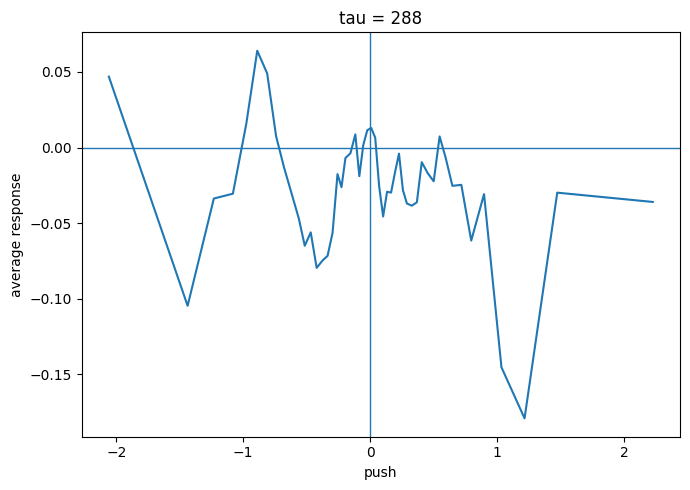

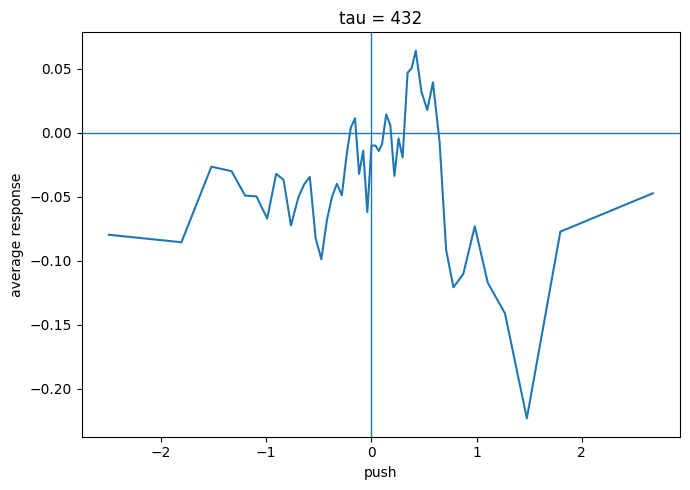

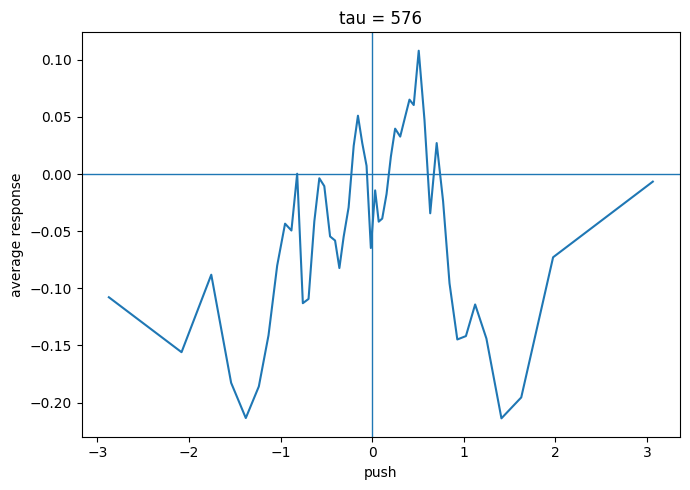

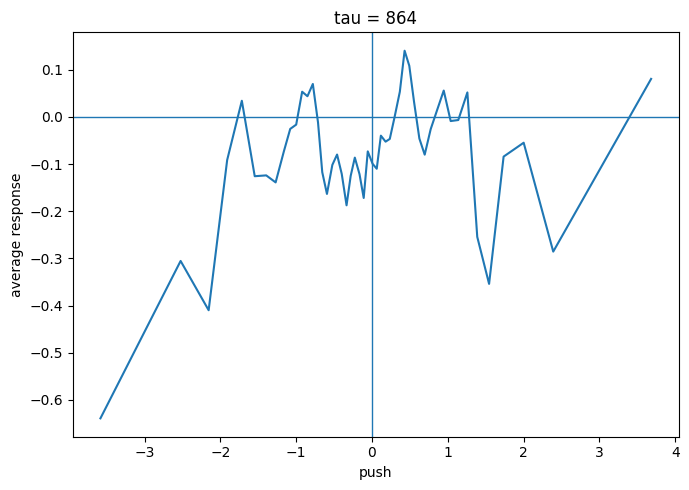

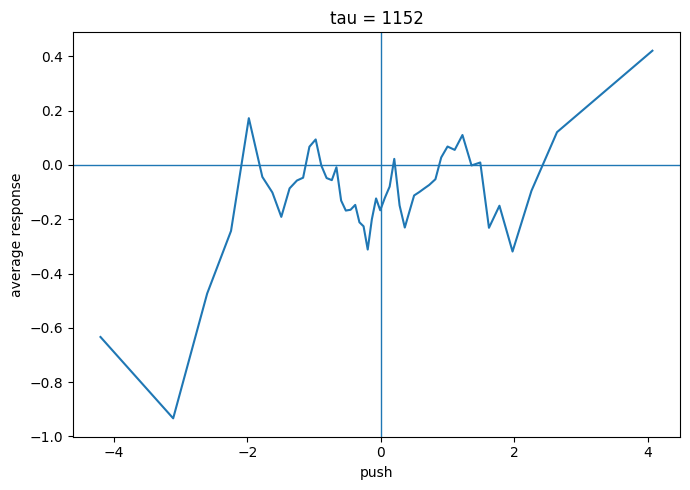

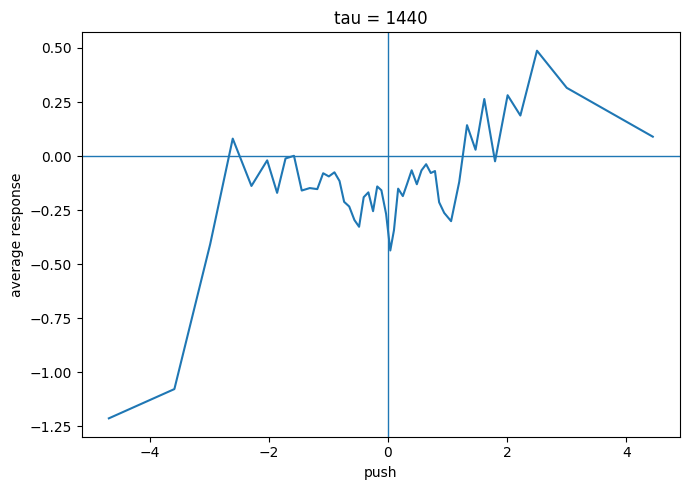

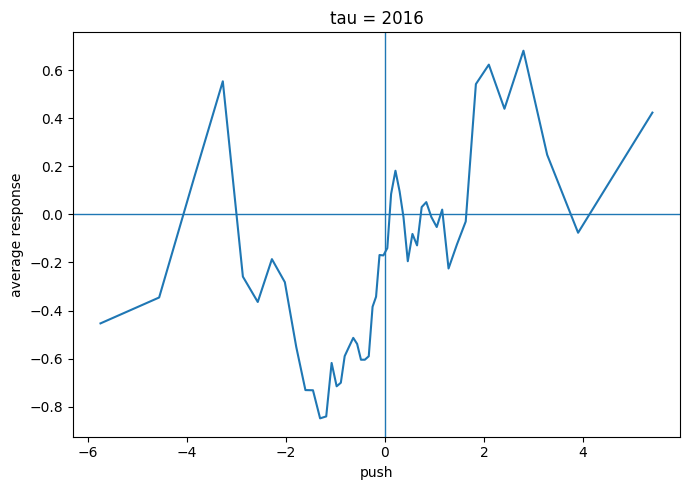

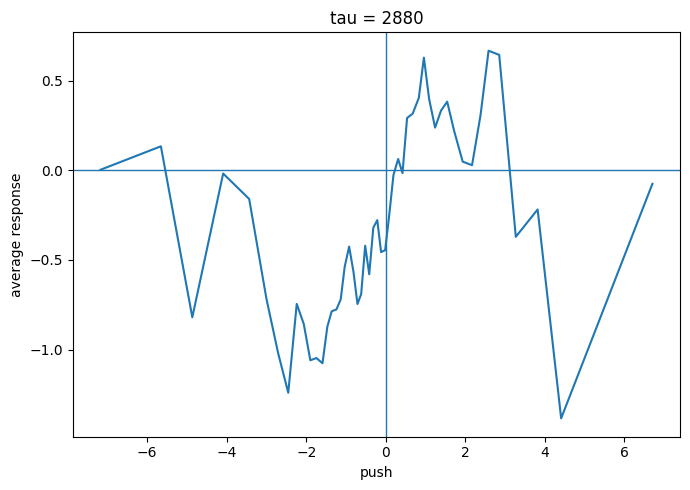

q=  1, VR = 1.0000
q= 21, VR = 0.9320
q= 41, VR = 0.9193
q= 61, VR = 0.9198
q= 81, VR = 0.9199
q=101, VR = 0.9211
q=121, VR = 0.9219
q=141, VR = 0.9202
q=161, VR = 0.9181
q=181, VR = 0.9128
q=201, VR = 0.9085
q=221, VR = 0.9046
q=241, VR = 0.9025
q=261, VR = 0.9000
q=281, VR = 0.8999
q=301, VR = 0.8980
q=321, VR = 0.8955
q=341, VR = 0.8922
q=361, VR = 0.8910
q=381, VR = 0.8899
q=401, VR = 0.8887
q=421, VR = 0.8892
q=441, VR = 0.8879
q=461, VR = 0.8860
q=481, VR = 0.8832
q=501, VR = 0.8807
q=521, VR = 0.8788
q=541, VR = 0.8778
q=561, VR = 0.8771
q=581, VR = 0.8757
q=601, VR = 0.8756
q=621, VR = 0.8751
q=641, VR = 0.8752
q=661, VR = 0.8742
q=681, VR = 0.8745
q=701, VR = 0.8740
q=721, VR = 0.8737
q=741, VR = 0.8734
q=761, VR = 0.8736
q=781, VR = 0.8734
q=801, VR = 0.8739
q=821, VR = 0.8755
q=841, VR = 0.8765
q=861, VR = 0.8775
q=881, VR = 0.8788
q=901, VR = 0.8802
q=921, VR = 0.8813
q=941, VR = 0.8821
q=961, VR = 0.8828
q=981, VR = 0.8831
q=1001, VR = 0.8832
q=1021, VR = 0.8833
q=1041, VR

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TYdata = pd.read_csv("TY-5minHLV.csv")
BTCdata = pd.read_csv("BTC-5minHLV.csv")

TYdata["numTime"] = pd.to_datetime(TYdata["Date"].astype(str)+" "+TYdata["Time"].astype(str))

BTCdata = BTCdata.reset_index(drop=True)
TYdata = TYdata.reset_index(drop=True)


end_time = TYdata["numTime"].max()

start_10y = end_time - pd.DateOffset(years=10)
TY_10y = TYdata[TYdata["numTime"] >= start_10y]

start_20y = end_time - pd.DateOffset(years=20)
TY_20y = TYdata[TYdata["numTime"] >= start_20y]


p = TYdata["Close"].dropna()
p =p.shift(-1)

from time_series_analysis import (push_response_test, variance_test)
if __name__ == "__main__":
    tau_list = [1, 2, 3, 4, 6, 8, 12, 16, 24, 32, 48,
                72, 96, 144, 192, 288, 432, 576,

                864, 1152, 1440, 2016, 2880]


    """

    for i in tau_list:
        push_response = push_response_test(price=TYdata,tau=i)
        plt.figure(figsize=(7,5))
        plt.plot(push_response["push_mean"],push_response["response_mean"])
        plt.axhline(0,linewidth=1)
        plt.axvline(0,linewidth=1)
        plt.xlabel("push")
        plt.ylabel("average response")
        plt.title(f"tau = {i}")
        plt.tight_layout()
        plt.show()
    """
BTCprice = BTCdata["Close"].dropna()



    for i in tau_list:
        push_response = push_response_test(price=TY_10y,tau=i)
        plt.figure(figsize=(7,5))
        plt.plot(push_response["push_mean"],push_response["response_mean"])
        plt.axhline(0,linewidth=1)
        plt.axvline(0,linewidth=1)
        plt.xlabel("push")
        plt.ylabel("average response")
        plt.title(f"tau = {i}")
        plt.tight_layout()
        plt.show()



    q_list = np.arange(1,2400,20)
    vr_list = []

    for q in q_list:
        vr=variance_test(TY_10y,q)
        vr_list.append(vr)
        print(f"q={q:>3}, VR = {vr:.4f}")
#As suggested by the professor, the graph show trend following around 1400bars, around one month. I perform the analysis not only for the whole data, but also the past 10 year, 20 year, show the similar properties. he said it's actually take some time to see the trend following, perhaps because economy or monetary policy expectations  change takes time.

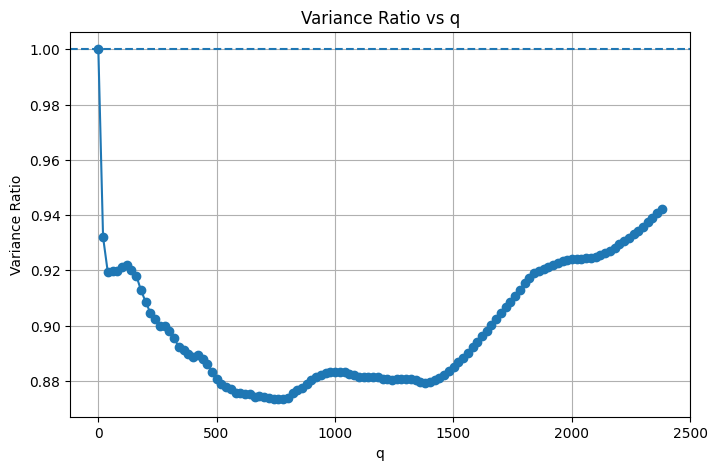

In [10]:
import matplotlib.pyplot as plt



plt.figure(figsize=(8,5))
plt.plot(q_list, vr_list, marker='o')
plt.axhline(1.0, linestyle='--')
plt.xlabel("q")
plt.ylabel("Variance Ratio")
plt.title("Variance Ratio vs q")
plt.grid(True)
plt.show()
# this is a naive variance ratio test in lecture note, as instructed by professor, i plot the variance ratio from q = 0, to q = 2500(q stands for how many bars)
#we see the slope going up after 1500, which is around 20days, its a sign of trend following. it also shows in short term, under 400 bars, around one week, it is mean reversion.

In [14]:
from scipy import stats
def variance_test_lm(price, q):

    """

    Lo-MacKinlay variance ratio test using log returns.

    Parameters

    ----------

    price : pd.DataFrame

        Must contain column 'Close'

    q : int

        Aggregation horizon

    Returns

    -------

    dict with keys:

        VR, Z1, Z2, p1, p2

    """

    if q < 2:

        raise ValueError("q must be at least 2.")

    p = price["Close"].dropna()

    if (p <= 0).any():

        raise ValueError("Close contains non-positive values; log undefined.")

    logp = np.log(p)

    r = logp.diff().dropna().to_numpy(dtype=np.float64)

    T = len(r)

    if T < q + 10:

        return {

            "VR": np.nan,

            "Z1": np.nan,

            "Z2": np.nan,

            "p1": np.nan,

            "p2": np.nan

        }

    mu = r.mean()

    dev = r - mu

    sum_sq = np.sum(dev ** 2)

    # 1-period variance

    sigma2_1 = sum_sq / (T - 1)

    # q-period overlapping returns

    csum = np.concatenate(([0.0], np.cumsum(r)))

    ret_q = csum[q:] - csum[:-q]   # length T-q+1

    # Lo-MacKinlay denominator correction

    m = q * (T - q + 1) * (1 - q / T)

    sigma2_q = np.sum((ret_q - q * mu) ** 2) / m

    VR = sigma2_q / sigma2_1

    # Homoskedastic test statistic

    phi = 2.0 * (2 * q - 1) * (q - 1) / (3.0 * q * T)

    Z1 = (VR - 1.0) / np.sqrt(phi)

    # Heteroskedasticity-robust test statistic

    dev_sq = dev ** 2

    denom = sum_sq ** 2

    delta_var = 0.0

    for j in range(1, q):

        weight = 2.0 * (q - j) / q

        if denom > 0:

            delta_j = T * np.sum(dev_sq[j:] * dev_sq[:-j]) / denom

        else:

            delta_j = 0.0

        delta_var += (weight ** 2) * delta_j

    Z2 = (VR - 1.0) / np.sqrt(delta_var) if delta_var > 0 else np.nan

    p1 = 2.0 * (1.0 - stats.norm.cdf(abs(Z1)))

    p2 = 2.0 * (1.0 - stats.norm.cdf(abs(Z2))) if np.isfinite(Z2) else np.nan

    return {

        "VR": VR,

        "Z1": Z1,

        "Z2": Z2,

        "p1": p1,

        "p2": p2

    }
if __name__ == "__main__":

    q_list = [2, 3, 6, 12, 24, 48, 72, 96, 144, 288]

    for q in q_list:

        out = variance_test_lm(TYdata, q)

        print(

            f"q={q:>4} | VR={out['VR']:.4f} | "

            f"Z1={out['Z1']:.4f} | p1={out['p1']:.4g} | "

            f"Z2={out['Z2']:.4f} | p2={out['p2']:.4g}"

        )



q=   2 | VR=0.9538 | Z1=-42.9025 | p1=0 | Z2=-0.0235 | p2=0.9813
q=   3 | VR=0.9398 | Z1=-37.5207 | p1=0 | Z2=-0.0206 | p2=0.9836
q=   6 | VR=0.9268 | Z1=-27.5336 | p1=0 | Z2=-0.0159 | p2=0.9873
q=  12 | VR=0.9259 | Z1=-18.3821 | p1=0 | Z2=-0.0113 | p2=0.991
q=  24 | VR=0.9249 | Z1=-12.7390 | p1=0 | Z2=-0.0085 | p2=0.9932
q=  48 | VR=0.9261 | Z1=-8.7275 | p1=0 | Z2=-0.0064 | p2=0.9949
q=  72 | VR=0.9389 | Z1=-5.8604 | p1=4.619e-09 | Z2=-0.0045 | p2=0.9964
q=  96 | VR=0.9477 | Z1=-4.3330 | p1=1.471e-05 | Z2=-0.0034 | p2=0.9973
q= 144 | VR=0.9470 | Z1=-3.5722 | p1=0.000354 | Z2=-0.0028 | p2=0.9978
q= 288 | VR=0.9363 | Z1=-3.0300 | p1=0.002446 | Z2=-0.0024 | p2=0.9981
